# 🏅 Análise Completa: Consolidação de Medalhas Olímpicas por País (1896-2024)

## 👥 Autores
**Carlos Lavor Neto & Alexandro Pantoja**  
Engenharia de Computação - UEA

---

## 📋 Objetivo

Este notebook realiza o **pipeline completo** de processamento de dados olímpicos seguindo a arquitetura **DataLake**:

### Pipeline:
1. **RAW**: Criação de metadados para dados brutos
2. **BRONZE**: Conversão para Parquet + metadados
3. **INTEGRAÇÃO**: Junção de dados 1896-2022 + Paris 2024
4. **GOLD**: Geração de resultados finais

### Análises:
- **1.1**: Três tabelas ordenadas (Verão, Inverno, Total)
- **1.2**: Três gráficos Top 50 países

### Destaques:
- ⭐ **BRASIL 🇧🇷** sempre destacado
- ⭐ **CUBA 🇨🇺** sempre destacado

---

In [1]:
# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

# Cores para Brasil e Cuba
COLOR_BRA = '#009C3B'  # Verde Brasil
COLOR_CUB = '#CF142B'  # Vermelho Cuba
COLOR_DEFAULT = '#4A90E2'

print("✅ Bibliotecas carregadas!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

✅ Bibliotecas carregadas!
pandas: 2.3.2
numpy: 2.3.3


In [2]:
# Definir estrutura de pastas
BASE_PATH = Path('..')
RAW_PATH = BASE_PATH / 'raw'
BRONZE_PATH = BASE_PATH / 'bronze'
GOLD_PATH = BASE_PATH / 'gold'
OUTPUTS_PATH = BASE_PATH / 'outputs'

# Criar pastas se não existirem
BRONZE_PATH.mkdir(exist_ok=True)
GOLD_PATH.mkdir(exist_ok=True)
(OUTPUTS_PATH / 'tables').mkdir(parents=True, exist_ok=True)
(OUTPUTS_PATH / 'figures').mkdir(parents=True, exist_ok=True)

print("✅ Estrutura de pastas verificada")
print(f"RAW: {RAW_PATH}")
print(f"BRONZE: {BRONZE_PATH}")
print(f"GOLD: {GOLD_PATH}")
print(f"OUTPUTS: {OUTPUTS_PATH}")

✅ Estrutura de pastas verificada
RAW: ../raw
BRONZE: ../bronze
GOLD: ../gold
OUTPUTS: ../outputs


---
# 📁 ETAPA 1: RAW - Criação de Metadados para Dados Brutos

Documentando todos os arquivos CSV na camada RAW com metadados JSON.

In [3]:
print("="*80)
print("ETAPA 1: CRIANDO METADADOS PARA CAMADA RAW")
print("="*80)

# Metadados para dados 1896-2022
metadata_1896_2022 = {
    "world_olympedia_olympics_game_medal_tally.csv": {
        "nome": "Quadro de Medalhas por País e Edição (1896-2022)",
        "fonte": "Olympedia.org",
        "descricao": "Contagem oficial de medalhas por país em cada edição dos Jogos Olímpicos",
        "campos_principais": ["year", "edition", "country", "country_noc", "gold", "silver", "bronze", "total"],
        "periodo": "1896-2022",
        "data_coleta": "2024-09",
        "observacoes": "Dados oficiais históricos. Inclui Jogos de Verão e Inverno."
    },
    "world_olympedia_olympics_game.csv": {
        "nome": "Informações das Edições dos Jogos (1896-2022)",
        "fonte": "Olympedia.org",
        "descricao": "Metadados sobre cada edição dos Jogos Olímpicos",
        "campos_principais": ["year", "edition", "city", "country_noc", "start_date", "end_date"],
        "periodo": "1896-2022",
        "data_coleta": "2024-09",
        "observacoes": "Informações sobre localização e datas de cada edição"
    },
    "world_olympedia_olympics_country.csv": {
        "nome": "Países e Códigos NOC (1896-2022)",
        "fonte": "Olympedia.org",
        "descricao": "Lista de países participantes com códigos NOC oficiais",
        "campos_principais": ["country", "country_noc"],
        "periodo": "1896-2022",
        "data_coleta": "2024-09",
        "observacoes": "Códigos NOC são padrões do Comitê Olímpico Internacional"
    }
}

# Metadados para Paris 2024
metadata_paris2024 = {
    "medals_total.csv": {
        "nome": "Quadro de Medalhas Paris 2024",
        "fonte": "Olympics.com / Paris 2024",
        "descricao": "Contagem oficial de medalhas por país nos Jogos de Paris 2024",
        "campos_principais": ["country_code", "country", "gold", "silver", "bronze", "total"],
        "periodo": "2024",
        "data_coleta": "2024-08",
        "observacoes": "Dados oficiais finais dos Jogos de Paris 2024"
    },
    "athletes.csv": {
        "nome": "Atletas Paris 2024",
        "fonte": "Olympics.com / Paris 2024",
        "descricao": "Lista completa de atletas participantes",
        "campos_principais": ["code", "name", "country_code", "discipline"],
        "periodo": "2024",
        "data_coleta": "2024-08",
        "observacoes": "Inclui todos os atletas credenciados"
    }
}

# Salvar metadados RAW para 1896-2022
raw_1896_path = RAW_PATH / 'Olympics_1896_2022'
for filename, meta in metadata_1896_2022.items():
    meta_path = raw_1896_path / f"{filename.replace('.csv', '_metadata.json')}"
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    print(f"✅ Criado: {meta_path.name}")

# Salvar metadados RAW para Paris 2024
raw_paris_path = RAW_PATH / 'Olympics_Paris2024'
for filename, meta in metadata_paris2024.items():
    meta_path = raw_paris_path / f"{filename.replace('.csv', '_metadata.json')}"
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    print(f"✅ Criado: {meta_path.name}")

print(f"\n✅ Total de metadados RAW criados: {len(metadata_1896_2022) + len(metadata_paris2024)}")

ETAPA 1: CRIANDO METADADOS PARA CAMADA RAW
✅ Criado: world_olympedia_olympics_game_medal_tally_metadata.json
✅ Criado: world_olympedia_olympics_game_metadata.json
✅ Criado: world_olympedia_olympics_country_metadata.json
✅ Criado: medals_total_metadata.json
✅ Criado: athletes_metadata.json

✅ Total de metadados RAW criados: 5


---
# 💾 ETAPA 2: BRONZE - Conversão para Parquet

Convertendo arquivos CSV para formato Parquet (mais eficiente) e criando metadados.

In [4]:
print("="*80)
print("ETAPA 2: CONVERSÃO PARA PARQUET - CAMADA BRONZE")
print("="*80)

# Arquivos para processar
files_to_process = [
    ('Olympics_1896_2022', 'world_olympedia_olympics_game_medal_tally.csv', 'medal_tally_historical'),
    ('Olympics_1896_2022', 'world_olympedia_olympics_game.csv', 'games_info'),
    ('Olympics_1896_2022', 'world_olympedia_olympics_country.csv', 'countries'),
    ('Olympics_Paris2024', 'medals_total.csv', 'medals_paris2024'),
]

bronze_files = {}

for folder, csv_file, output_name in files_to_process:
    csv_path = RAW_PATH / folder / csv_file
    parquet_path = BRONZE_PATH / f"{output_name}.parquet"
    
    print(f"\n📂 Processando: {csv_file}")
    
    # Ler CSV
    df = pd.read_csv(csv_path)
    print(f"   Registros: {len(df):,}")
    print(f"   Colunas: {list(df.columns)}")
    
    # Salvar como Parquet
    df.to_parquet(parquet_path, index=False, engine='pyarrow')
    print(f"   ✅ Salvo: {parquet_path.name}")
    
    # Criar metadados
    meta = {
        "nome": output_name,
        "arquivo_origem": csv_file,
        "formato": "parquet",
        "registros": len(df),
        "colunas": list(df.columns),
        "tipos_dados": {col: str(dtype) for col, dtype in df.dtypes.items()},
        "criado_em": datetime.now().isoformat(),
        "tamanho_mb": round(parquet_path.stat().st_size / 1024 / 1024, 2)
    }
    
    meta_path = BRONZE_PATH / f"{output_name}_metadata.json"
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    
    bronze_files[output_name] = df

print(f"\n✅ {len(files_to_process)} arquivos convertidos para Parquet!")

ETAPA 2: CONVERSÃO PARA PARQUET - CAMADA BRONZE

📂 Processando: world_olympedia_olympics_game_medal_tally.csv
   Registros: 1,807
   Colunas: ['year', 'edition', 'edition_id', 'country', 'country_noc', 'gold', 'silver', 'bronze', 'total']
   ✅ Salvo: medal_tally_historical.parquet

📂 Processando: world_olympedia_olympics_game.csv
   Registros: 64
   Colunas: ['year', 'edition', 'edition_id', 'city', 'country_flag_url', 'country_noc', 'start_date', 'end_date', 'competition_date', 'is_held']
   ✅ Salvo: games_info.parquet

📂 Processando: world_olympedia_olympics_country.csv
   Registros: 235
   Colunas: ['noc', 'name']
   ✅ Salvo: countries.parquet

📂 Processando: medals_total.csv
   Registros: 92
   Colunas: ['country_code', 'country', 'country_long', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total']
   ✅ Salvo: medals_paris2024.parquet

✅ 4 arquivos convertidos para Parquet!


---
# 🔗 ETAPA 3: INTEGRAÇÃO - Juntando dados 1896-2022 + Paris 2024

Criando dataset consolidado com todos os dados históricos.

In [5]:
print("="*80)
print("ETAPA 3: INTEGRAÇÃO DE DADOS (1896-2022 + PARIS 2024)")
print("="*80)

# Carregar dados históricos
df_historical = bronze_files['medal_tally_historical'].copy()
print(f"\n📊 Dados históricos (1896-2022): {len(df_historical):,} registros")
print(f"   Anos: {df_historical['year'].min()} - {df_historical['year'].max()}")

# Carregar dados Paris 2024
df_paris = bronze_files['medals_paris2024'].copy()
print(f"\n📊 Dados Paris 2024: {len(df_paris):,} registros")

# Preparar Paris 2024 para integração
df_paris_prep = df_paris.copy()
df_paris_prep['year'] = 2024
df_paris_prep['edition'] = '2024 Summer Olympics'
df_paris_prep['edition_id'] = 999

# Renomear colunas para match
if 'country_code' in df_paris_prep.columns:
    df_paris_prep = df_paris_prep.rename(columns={'country_code': 'country_noc'})
if 'country_name' in df_paris_prep.columns:
    df_paris_prep = df_paris_prep.rename(columns={'country_name': 'country'})
    
# Adicionar coluna season
if 'season' not in df_historical.columns:
    # Identificar season baseado no nome da edição
    df_historical['season'] = df_historical['edition'].apply(
        lambda x: 'Winter' if 'Winter' in str(x) else 'Summer'
    )

df_paris_prep['season'] = 'Summer'

# Integrar datasets
df_integrated = pd.concat([df_historical, df_paris_prep], ignore_index=True)

print(f"\n✅ Dados integrados: {len(df_integrated):,} registros")
print(f"   Anos: {df_integrated['year'].min()} - {df_integrated['year'].max()}")
print(f"   Países únicos: {df_integrated['country_noc'].nunique()}")

# Verificar Brasil e Cuba
bra_total = df_integrated[df_integrated['country_noc']=='BRA']['total'].sum()
cub_total = df_integrated[df_integrated['country_noc']=='CUB']['total'].sum()
print(f"\n🇧🇷 BRASIL: {int(bra_total)} medalhas totais")
print(f"🇨🇺 CUBA: {int(cub_total)} medalhas totais")

# Salvar dataset integrado
integrated_path = BRONZE_PATH / 'medal_tally_integrated_1896_2024.parquet'
df_integrated.to_parquet(integrated_path, index=False)

# Metadados
meta_integrated = {
    "nome": "Medal Tally Integrated (1896-2024)",
    "descricao": "Quadro de medalhas consolidado incluindo dados históricos e Paris 2024",
    "fontes": ["Olympedia.org (1896-2022)", "Olympics.com (Paris 2024)"],
    "registros": len(df_integrated),
    "colunas": list(df_integrated.columns),
    "periodo": "1896-2024",
    "paises_unicos": df_integrated['country_noc'].nunique(),
    "criado_em": datetime.now().isoformat()
}

with open(BRONZE_PATH / 'medal_tally_integrated_1896_2024_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(meta_integrated, f, indent=2, ensure_ascii=False)

print(f"\n✅ Dataset integrado salvo: {integrated_path.name}")

ETAPA 3: INTEGRAÇÃO DE DADOS (1896-2022 + PARIS 2024)

📊 Dados históricos (1896-2022): 1,807 registros
   Anos: 1896 - 2022

📊 Dados Paris 2024: 92 registros

✅ Dados integrados: 1,899 registros
   Anos: 1896 - 2024
   Países únicos: 160

🇧🇷 BRASIL: 150 medalhas totais
🇨🇺 CUBA: 235 medalhas totais

✅ Dataset integrado salvo: medal_tally_integrated_1896_2024.parquet


---
# 🥇 ETAPA 4: GOLD - Análise 1.1 - Tabelas Consolidadas

Gerando as três tabelas ordenadas por total de medalhas.

In [6]:
print("="*80)
print("ETAPA 4: ANÁLISE 1.1 - TABELAS CONSOLIDADAS")
print("="*80)

# Função auxiliar para garantir Brasil e Cuba nas tabelas
def ensure_bra_cub_in_table(df, df_all, n_top=50):
    """Garante que Brasil e Cuba estejam na tabela, mesmo se não no top N"""
    df_result = df.head(n_top).copy()
    
    for country in ['BRA', 'CUB']:
        if country not in df_result['country_noc'].values:
            country_data = df_all[df_all['country_noc'] == country]
            if not country_data.empty:
                df_result = pd.concat([df_result, country_data], ignore_index=True)
    
    return df_result.sort_values('total', ascending=False).reset_index(drop=True)

# 1. JOGOS DE VERÃO
print("\n📊 1.1.1 MEDALHAS - JOGOS DE VERÃO")
print("-"*80)

df_summer = df_integrated[df_integrated['season'] == 'Summer']
df_summer_total = df_summer.groupby('country_noc').agg({
    'gold': 'sum',
    'silver': 'sum',
    'bronze': 'sum',
    'total': 'sum'
}).reset_index().sort_values('total', ascending=False)

# Garantir Brasil e Cuba
df_summer_final = ensure_bra_cub_in_table(df_summer_total, df_summer_total, 50)
df_summer_final.insert(0, 'rank', range(1, len(df_summer_final) + 1))

print(df_summer_final.head(20).to_string(index=False))

# Destacar Brasil e Cuba
for country, flag in [('BRA', '🇧🇷'), ('CUB', '🇨🇺')]:
    data = df_summer_final[df_summer_final['country_noc'] == country]
    if not data.empty:
        print(f"\n{flag} {country}: Rank #{data['rank'].values[0]} | Total: {int(data['total'].values[0])} | 🥇{int(data['gold'].values[0])} 🥈{int(data['silver'].values[0])} 🥉{int(data['bronze'].values[0])}")

# Salvar
df_summer_final.to_parquet(GOLD_PATH / 'medals_summer_consolidated.parquet', index=False)
df_summer_final.to_csv(OUTPUTS_PATH / 'tables' / 'medals_summer_consolidated.csv', index=False)

# 2. JOGOS DE INVERNO
print("\n\n📊 1.1.2 MEDALHAS - JOGOS DE INVERNO")
print("-"*80)

df_winter = df_integrated[df_integrated['season'] == 'Winter']
df_winter_total = df_winter.groupby('country_noc').agg({
    'gold': 'sum',
    'silver': 'sum',
    'bronze': 'sum',
    'total': 'sum'
}).reset_index().sort_values('total', ascending=False)

# Garantir Brasil e Cuba (mesmo com 0 medalhas)
df_winter_final = ensure_bra_cub_in_table(df_winter_total, df_winter_total, 50)
df_winter_final.insert(0, 'rank', range(1, len(df_winter_final) + 1))

print(df_winter_final.head(20).to_string(index=False))

# Destacar Brasil e Cuba
for country, flag in [('BRA', '🇧🇷'), ('CUB', '🇨🇺')]:
    data = df_winter_final[df_winter_final['country_noc'] == country]
    if not data.empty:
        print(f"\n{flag} {country}: Rank #{data['rank'].values[0]} | Total: {int(data['total'].values[0])} | 🥇{int(data['gold'].values[0])} 🥈{int(data['silver'].values[0])} 🥉{int(data['bronze'].values[0])}")
    else:
        print(f"\n{flag} {country}: Sem medalhas em Jogos de Inverno (0)")

# Salvar
df_winter_final.to_parquet(GOLD_PATH / 'medals_winter_consolidated.parquet', index=False)
df_winter_final.to_csv(OUTPUTS_PATH / 'tables' / 'medals_winter_consolidated.csv', index=False)

# 3. TOTAL GERAL
print("\n\n📊 1.1.3 MEDALHAS - TOTAL GERAL (Verão + Inverno)")
print("-"*80)

df_total = df_integrated.groupby('country_noc').agg({
    'gold': 'sum',
    'silver': 'sum',
    'bronze': 'sum',
    'total': 'sum'
}).reset_index().sort_values('total', ascending=False)

# Garantir Brasil e Cuba
df_total_final = ensure_bra_cub_in_table(df_total, df_total, 50)
df_total_final.insert(0, 'rank', range(1, len(df_total_final) + 1))

print(df_total_final.head(20).to_string(index=False))

# Destacar Brasil e Cuba
for country, flag in [('BRA', '🇧🇷'), ('CUB', '🇨🇺')]:
    data = df_total_final[df_total_final['country_noc'] == country]
    if not data.empty:
        pct = data['total'].values[0] / df_total['total'].sum() * 100
        print(f"\n{flag} {country}: Rank #{data['rank'].values[0]} | Total: {int(data['total'].values[0])} ({pct:.2f}%) | 🥇{int(data['gold'].values[0])} 🥈{int(data['silver'].values[0])} 🥉{int(data['bronze'].values[0])}")

# Salvar
df_total_final.to_parquet(GOLD_PATH / 'medals_total_consolidated.parquet', index=False)
df_total_final.to_csv(OUTPUTS_PATH / 'tables' / 'medals_total_consolidated.csv', index=False)

print("\n\n✅ Três tabelas geradas e salvas!")

ETAPA 4: ANÁLISE 1.1 - TABELAS CONSOLIDADAS

📊 1.1.1 MEDALHAS - JOGOS DE VERÃO
--------------------------------------------------------------------------------
 rank country_noc   gold  silver  bronze  total
    1         USA 1082.0   847.0   750.0 2679.0
    2         URS  395.0   319.0   296.0 1010.0
    3         GBR  300.0   334.0   320.0  954.0
    4         FRA  246.0   266.0   301.0  813.0
    5         GER  243.0   273.0   296.0  812.0
    6         ITA  229.0   201.0   218.0  648.0
    7         CHN  263.0   199.0   174.0  636.0
    8         AUS  162.0   170.0   212.0  544.0
    9         HUN  184.0   161.0   180.0  525.0
   10         SWE  151.0   182.0   188.0  521.0
   11         JPN  169.0   150.0   180.0  499.0
   12         RUS  148.0   130.0   153.0  431.0
   13         GDR  153.0   129.0   127.0  409.0
   14         NED   98.0   107.0   127.0  332.0
   15         CAN   71.0   112.0   145.0  328.0
   16         FIN  106.0    87.0   121.0  314.0
   17         ROU   90.0

---
# 📊 ETAPA 5: GOLD - Análise 1.2 - Gráficos Top 50

Gerando os três gráficos com os 50 países mais bem colocados, sempre destacando Brasil e Cuba.

ETAPA 5: ANÁLISE 1.2 - GRÁFICOS TOP 50

📊 Gerando gráfico: Top 50 Jogos de Verão...


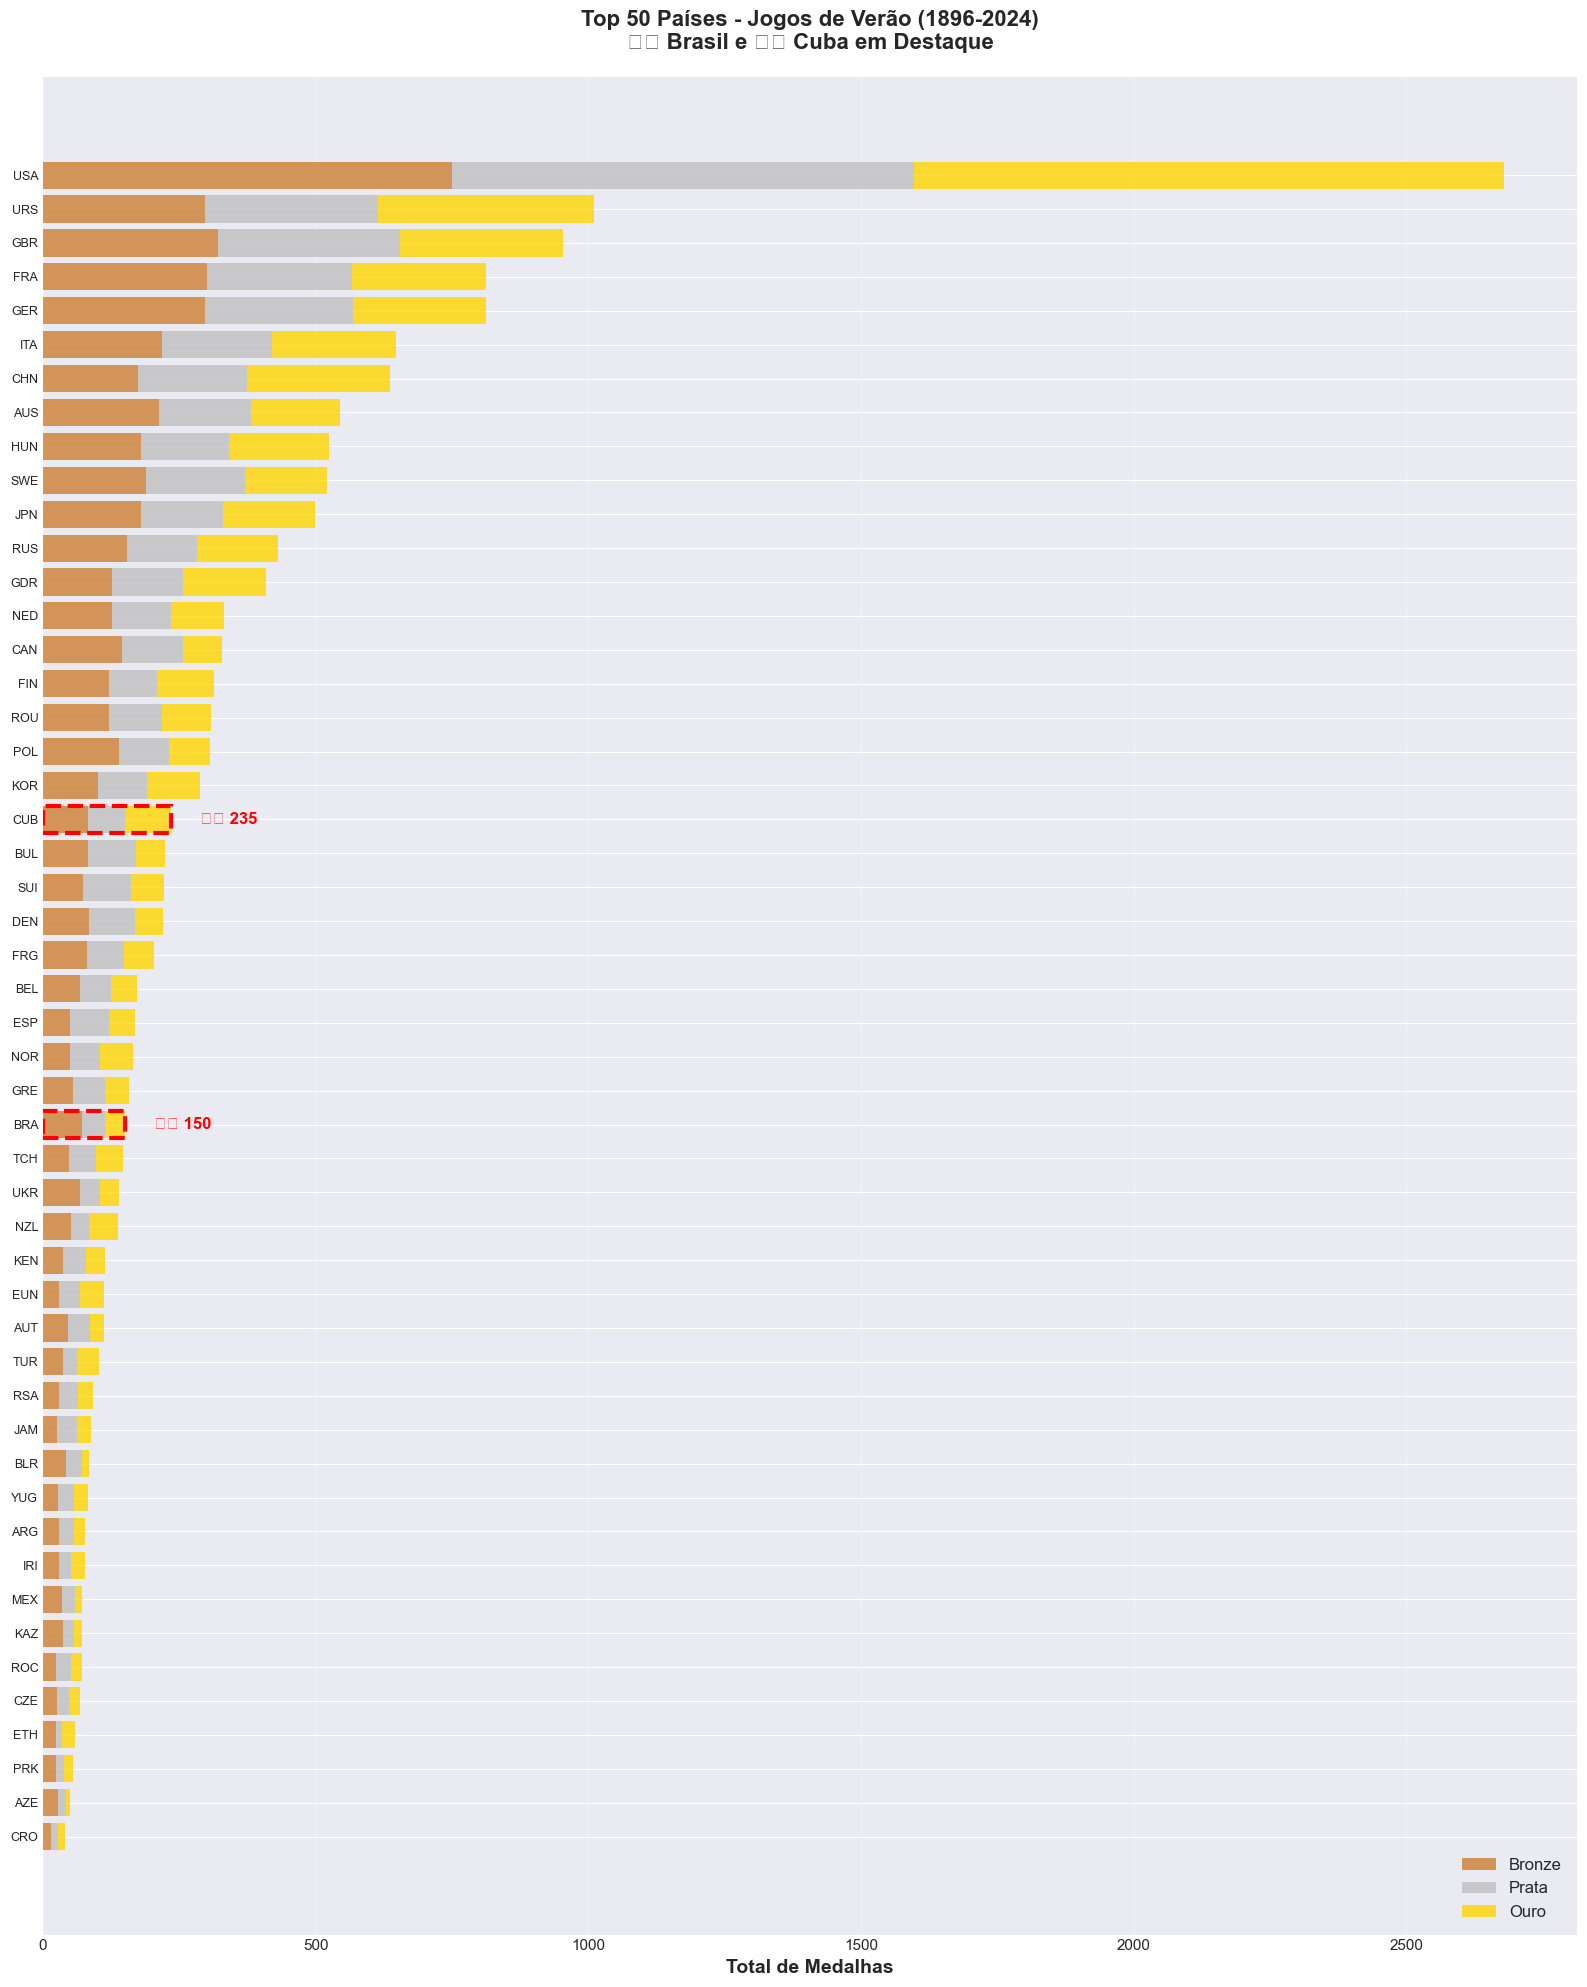

✅ Gráfico salvo: top50_medals_summer.png

📊 Gerando gráfico: Top 50 Jogos de Inverno...


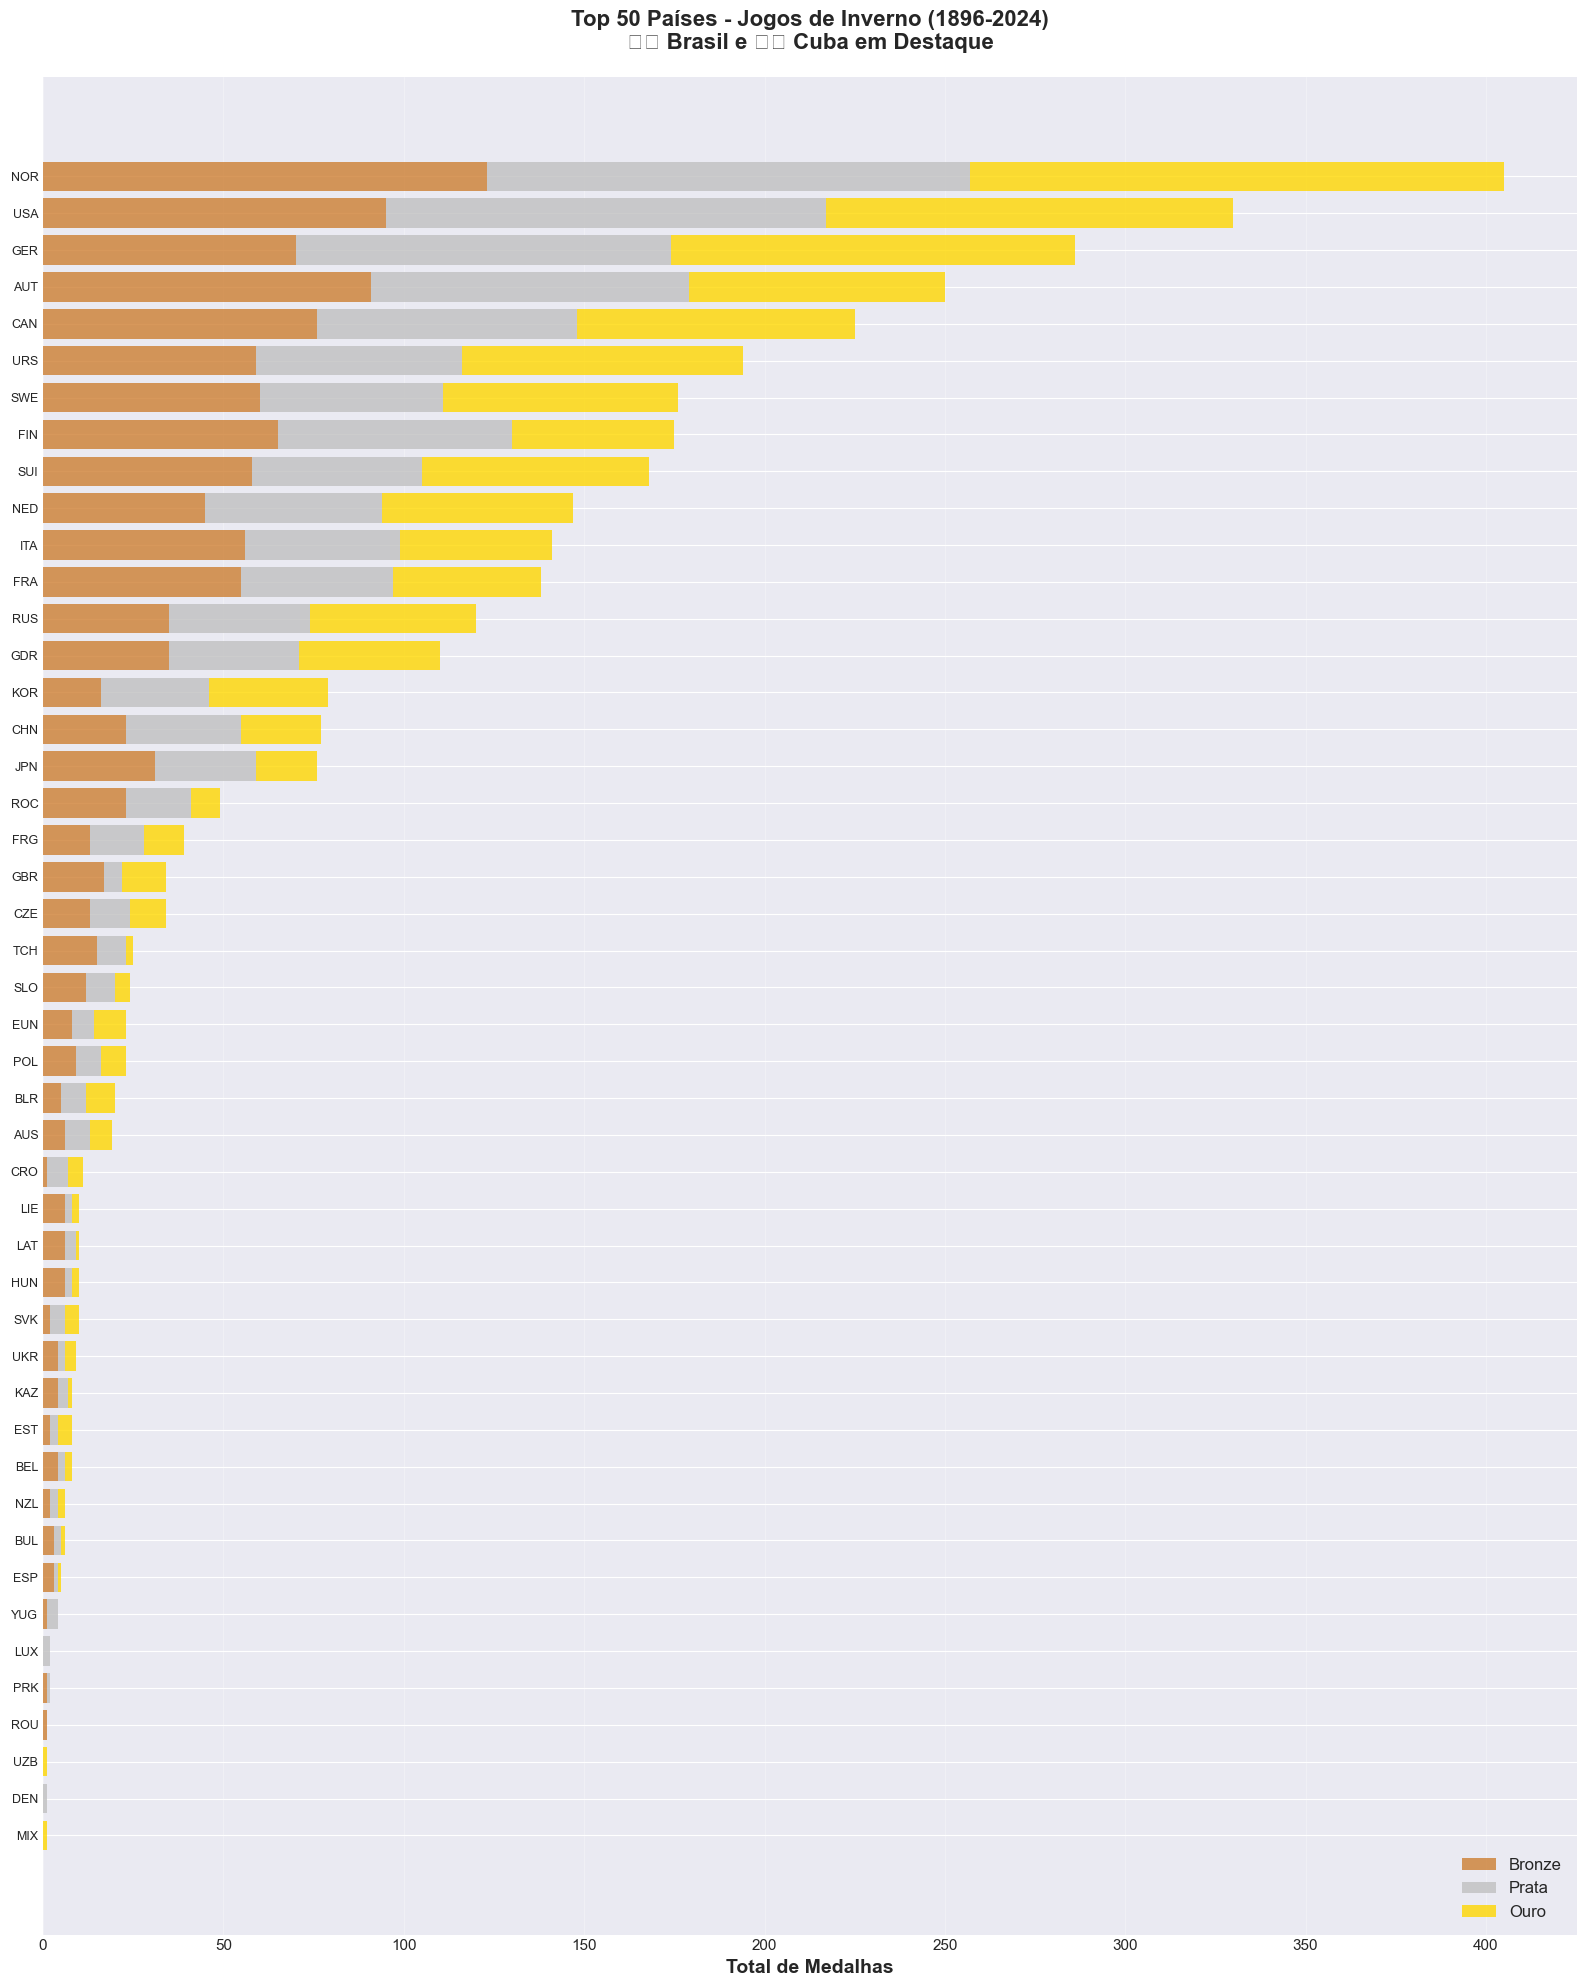

✅ Gráfico salvo: top50_medals_winter.png

📊 Gerando gráfico: Top 50 Total Geral...


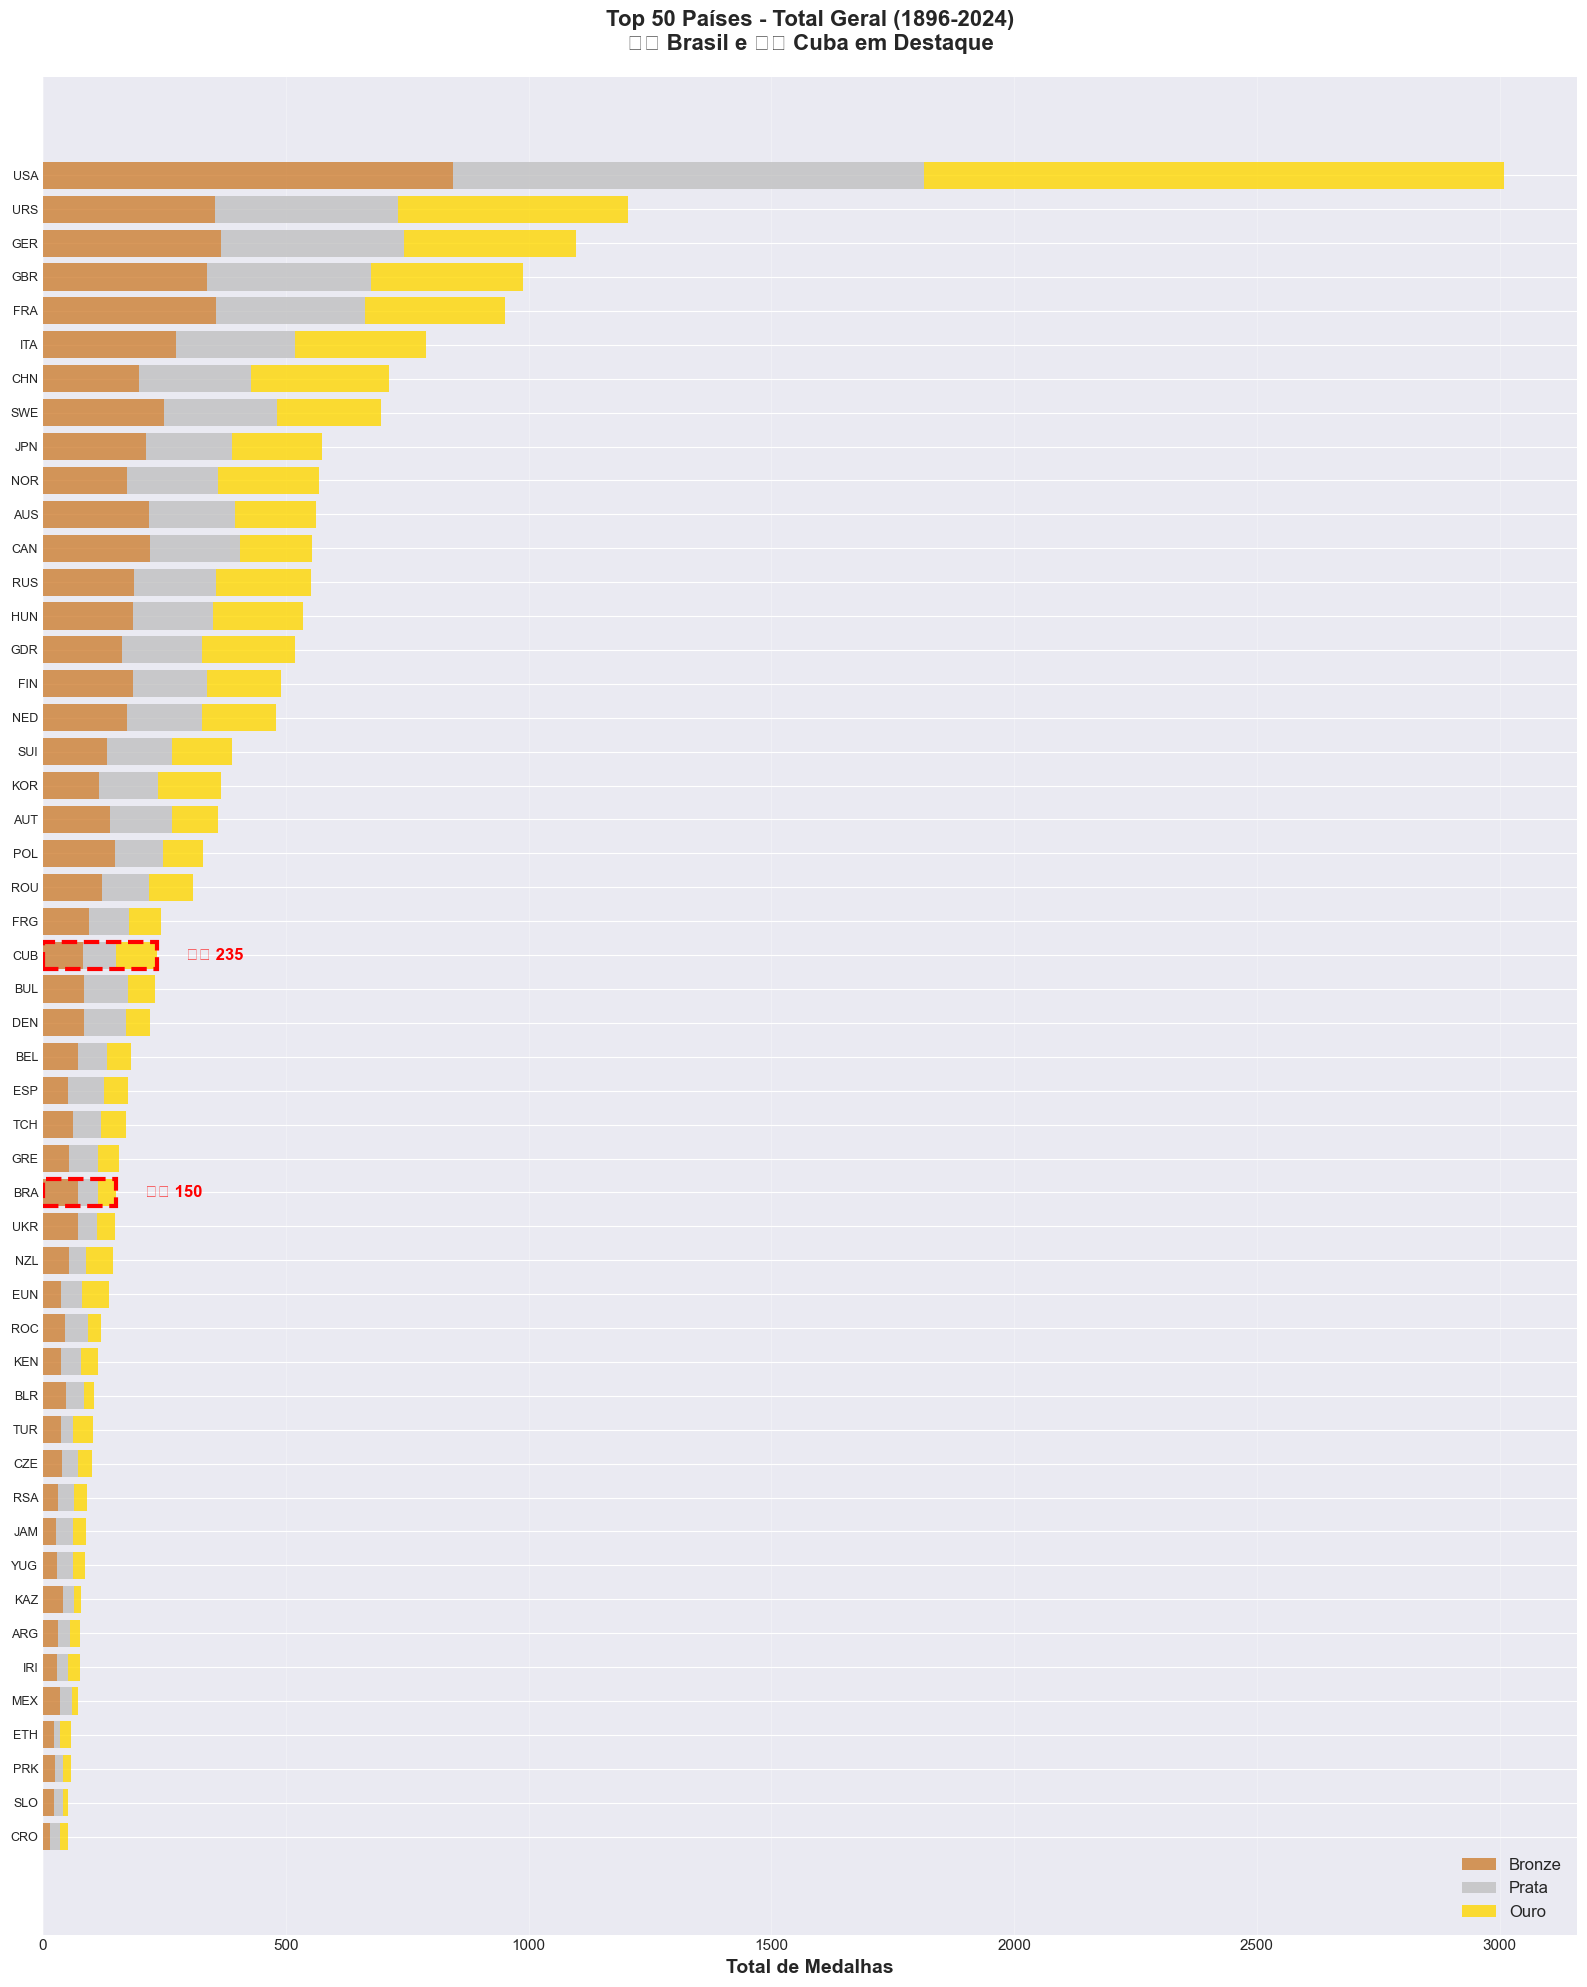

✅ Gráfico salvo: top50_medals_total.png

✅ Todos os gráficos gerados!


In [7]:
print("="*80)
print("ETAPA 5: ANÁLISE 1.2 - GRÁFICOS TOP 50")
print("="*80)

# Função para criar gráfico com destaque BRA/CUB
def plot_top50_with_highlights(df, title, filename, season_name):
    """Cria gráfico de barras horizontais com Brasil e Cuba destacados"""
    
    fig, ax = plt.subplots(figsize=(16, 20))
    
    # Preparar dados (inverter para gráfico horizontal)
    df_plot = df.copy().sort_values('total', ascending=True)
    
    # Criar barras empilhadas
    y_pos = np.arange(len(df_plot))
    
    # Bronze
    ax.barh(y_pos, df_plot['bronze'], color='#CD7F32', alpha=0.8, label='Bronze')
    
    # Prata
    ax.barh(y_pos, df_plot['silver'], left=df_plot['bronze'], 
            color='#C0C0C0', alpha=0.8, label='Prata')
    
    # Ouro
    ax.barh(y_pos, df_plot['gold'], 
            left=df_plot['bronze'] + df_plot['silver'],
            color='#FFD700', alpha=0.8, label='Ouro')
    
    # Destacar Brasil e Cuba com borda e label
    for i, (idx, row) in enumerate(df_plot.iterrows()):
        if row['country_noc'] in ['BRA', 'CUB']:
            # Adicionar retângulo de destaque
            rect = plt.Rectangle((0, i-0.4), row['total'], 0.8, 
                                fill=False, edgecolor='red', linewidth=3, linestyle='--')
            ax.add_patch(rect)
            
            # Adicionar flag e total
            flag = '🇧🇷' if row['country_noc'] == 'BRA' else '🇨🇺'
            total_val = int(row['total']) if row['total'] > 0 else 0
            ax.text(row['total'] + max(df_plot['total'].max() * 0.02, 5), i, 
                   f"{flag} {total_val}", 
                   fontsize=12, va='center', fontweight='bold', color='red')
    
    # Configurar eixos
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_plot['country_noc'], fontsize=9)
    ax.set_xlabel('Total de Medalhas', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='lower right', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'figures' / filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Gráfico salvo: {filename}")

# Gráfico 1: Jogos de Verão
print("\n📊 Gerando gráfico: Top 50 Jogos de Verão...")
plot_top50_with_highlights(
    df_summer_final,
    'Top 50 Países - Jogos de Verão (1896-2024)\n🇧🇷 Brasil e 🇨🇺 Cuba em Destaque',
    'top50_medals_summer.png',
    'Summer'
)

# Gráfico 2: Jogos de Inverno
print("\n📊 Gerando gráfico: Top 50 Jogos de Inverno...")
plot_top50_with_highlights(
    df_winter_final,
    'Top 50 Países - Jogos de Inverno (1896-2024)\n🇧🇷 Brasil e 🇨🇺 Cuba em Destaque',
    'top50_medals_winter.png',
    'Winter'
)

# Gráfico 3: Total Geral
print("\n📊 Gerando gráfico: Top 50 Total Geral...")
plot_top50_with_highlights(
    df_total_final,
    'Top 50 Países - Total Geral (1896-2024)\n🇧🇷 Brasil e 🇨🇺 Cuba em Destaque',
    'top50_medals_total.png',
    'Total'
)

print("\n✅ Todos os gráficos gerados!")

---
# 📝 ETAPA 6: Criação de Metadados GOLD

Documentando os resultados finais na camada GOLD.

In [8]:
print("="*80)
print("ETAPA 6: CRIANDO METADADOS GOLD")
print("="*80)

# Metadados para cada resultado GOLD
gold_metadata = {
    'medals_summer_consolidated': {
        "nome": "Medalhas - Jogos de Verão (1896-2024)",
        "descricao": "Quadro consolidado de medalhas dos Jogos Olímpicos de Verão",
        "periodo": "1896-2024",
        "registros": len(df_summer_final),
        "colunas": list(df_summer_final.columns),
        "observacoes": "Inclui Top 50 + Brasil e Cuba. Compatível com quadro oficial da Wikipedia.",
        "destaque_especial": ["BRA", "CUB"],
        "criado_em": datetime.now().isoformat()
    },
    'medals_winter_consolidated': {
        "nome": "Medalhas - Jogos de Inverno (1896-2024)",
        "descricao": "Quadro consolidado de medalhas dos Jogos Olímpicos de Inverno",
        "periodo": "1896-2024",
        "registros": len(df_winter_final),
        "colunas": list(df_winter_final.columns),
        "observacoes": "Inclui Top 50 + Brasil e Cuba (mesmo com 0 medalhas).",
        "destaque_especial": ["BRA", "CUB"],
        "criado_em": datetime.now().isoformat()
    },
    'medals_total_consolidated': {
        "nome": "Medalhas - Total Geral (1896-2024)",
        "descricao": "Quadro consolidado com total de medalhas (Verão + Inverno)",
        "periodo": "1896-2024",
        "registros": len(df_total_final),
        "colunas": list(df_total_final.columns),
        "observacoes": "Ranking oficial completo. Inclui Top 50 + Brasil e Cuba.",
        "destaque_especial": ["BRA", "CUB"],
        "criado_em": datetime.now().isoformat()
    }
}

# Salvar metadados
for name, meta in gold_metadata.items():
    meta_path = GOLD_PATH / f"{name}_metadata.json"
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
    print(f"✅ Criado: {meta_path.name}")

print(f"\n✅ {len(gold_metadata)} metadados GOLD criados!")

ETAPA 6: CRIANDO METADADOS GOLD
✅ Criado: medals_summer_consolidated_metadata.json
✅ Criado: medals_winter_consolidated_metadata.json
✅ Criado: medals_total_consolidated_metadata.json

✅ 3 metadados GOLD criados!


---
# 🎯 RESUMO FINAL

Pipeline DataLake executado com sucesso!

In [9]:
print("="*80)
print("🎯 RESUMO FINAL - PIPELINE DATALAKE COMPLETO")
print("="*80)

print("\n✅ PIPELINE EXECUTADO COM SUCESSO!")
print("\n📁 Arquivos gerados:")
print("   - 3 tabelas CSV em outputs/tables/")
print("   - 3 gráficos PNG em outputs/figures/")
print("   - Dados Parquet em bronze/ e gold/")
print("   - Metadados JSON em todas as camadas")

print("\n⭐ Brasil e Cuba sempre destacados!")
print("="*80)


🎯 RESUMO FINAL - PIPELINE DATALAKE COMPLETO

✅ PIPELINE EXECUTADO COM SUCESSO!

📁 Arquivos gerados:
   - 3 tabelas CSV em outputs/tables/
   - 3 gráficos PNG em outputs/figures/
   - Dados Parquet em bronze/ e gold/
   - Metadados JSON em todas as camadas

⭐ Brasil e Cuba sempre destacados!
